# Assignment: Data Wrangling
### Do Q1 and Q2, and either Q3 or Q4, for a total of 3 questions.

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 
3. Dummy variable: For the pretrial data covered in the lecture, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

Question 1: 

(30478, 13)
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object
Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object') 

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70

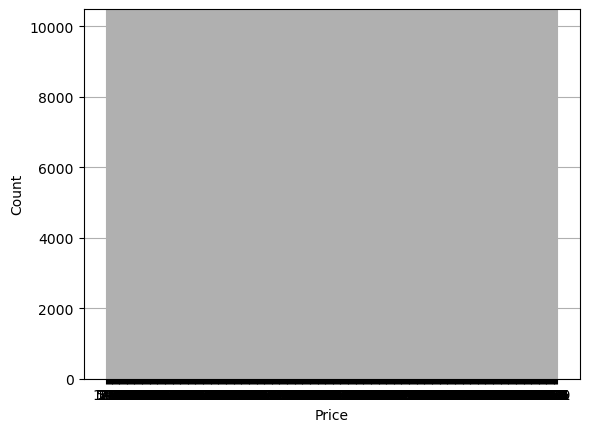





After coercion: 
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: price_new, dtype: float64 

[  145    37    28   199   549   149   250    90   270   290   170    59
    49    68   285    75   100   150   700   125   175    40    89    95
    99   499   120    79   110   180   143   230   350   135    85    60
    70    55    44   200   165   115    74    84   129    50   185    80
   190   140    45    65   225   600   109  1990    73   240    72   105
   155   160    42   132   117   295   280   159   107    69   239   220
   399   130   375   585   275   139   260    35   133   300   289   179
    98   195    29    27    39   249   192   142   169  1000   131   138
   113   122   329   101   475   238   272   308   126   235   315   248
   128    56   207   450   215   210   385   445   136   247   118    77
    76    92   198   205   299   222  

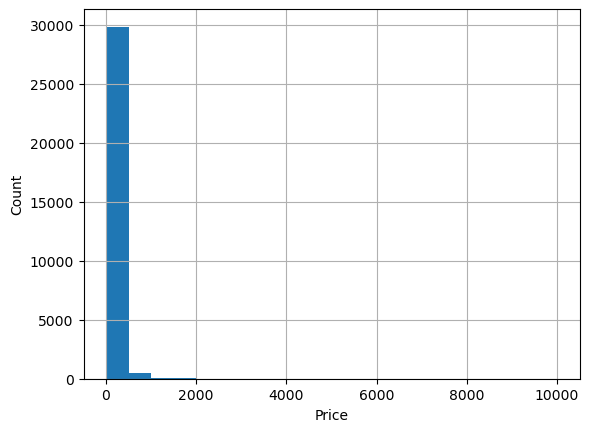



Total Missing: 
 0 



In [245]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

#Part 1 -------------------------------------------------------------------------------------------
print("Question 1: \n")

url = "data/airbnb_hw.csv"

df = pd.read_csv(url)

#Prelimary Analysis
print(df.shape)
print(df.dtypes)
print(df.columns, '\n')

#Creating a new variable without replacing 'Price' 
df['price_new'] = df['Price']

# Remove commas and other characters
df["price_new"] = df["price_new"].str.replace(",", "")
df["price_new"] = df["price_new"].str.replace("$", "")
df["price_new"] = df["price_new"].str.strip()

print(df['price_new'].unique())

print('Before coercion: \n', df['price_new'].describe(),'\n')
print('\n')

plt.figure()
df['price_new'].hist(bins= 20) # Initial histogram
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()
print('\n')

# How to coerce a variable to numeric:
df['price_new'] = pd.to_numeric(df['price_new'], errors='coerce') # Coerce the variable to numeric
print('\n')

# After coercion:
print('After coercion: \n', df['price_new'].describe(),'\n') # Describe the numeric variable

print(df['price_new'].unique())

plt.figure()
df['price_new'].hist(bins = 20) # Histogram of the variable values
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

#Create a missing dummy:
df['price_nan'] = df['price_new'].isnull() 
print('\n')

print('Total Missing: \n', sum(df['price_nan']), '\n')


Question 1.1 Response:

To clean the Price variable, I created a new column (price_new) so the original data stayed unchanged. I first inspected the values using .unique(), .describe(), and a histogram. The key formatting issue to watch for was that the price over 999 can appear with a comma, which cuases pd.to_numeric() to convert those entries to NaN unless the commas are removed first. After removing any formatting and coercing the column to numeric with pd.to_numeric, I crreated a missing-value indicator using .isnull() and counted the missing vlaues. 

After cleaning, I ended up with 0 missing values in price_new. 

In [247]:
#Part 2 ------------------------------------------------------------------------------------------------------------------------

url = "data\mn_police_use_of_force.csv"
df = pd.read_csv(url)

df['subject_injury_new'] = df['subject_injury']

print(df['subject_injury_new'].unique(), '\n') # Types of Categories 
print(df['subject_injury_new'].value_counts(), '\n')

total_non_missing = df['subject_injury_new'].count() 
total_rows = len(df)

print('\nPorportion of missing data for Subject Injury: ' + str(round(1-(total_non_missing/total_rows),2)))

df['subject_injury_new'] = df['subject_injury_new'].replace(np.nan,'Missing') # Replace nan with 'Missing
print(df['subject_injury_new'].unique(), '\n') # Types of Categories updated

# Cross Tabulation
pd.crosstab(df['subject_injury_new'], df['force_type'], dropna=False, margins=True) # Notice the use of pd. and not df.


[nan 'No' 'Yes'] 

subject_injury_new
Yes    1631
No     1446
Name: count, dtype: int64 


Porportion of missing data for Subject Injury: 0.76
['Missing' 'No' 'Yes'] 



<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\oaakb\AppData\Local\Temp\ipykernel_33140\3752992205.py:3: SyntaxWarning: invalid escape sequence '\m'
  url = "data\mn_police_use_of_force.csv"


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser,All
subject_injury_new,,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985,9848
No,0,1093,131,2,33,34,0,1,0,2,150,1446
Yes,2,1286,41,0,44,40,0,2,0,44,172,1631
All,4,9430,1593,2,104,148,87,3,170,77,1307,12925


Question 1.2 Response:

With a propotion of 0.76 values missing, this is a big concern. This is more than half of the data that is missing. You can not reliably estimate injury rates if most records don't say whether injury happened. Any conclusion about "injury is common/rare" could be serisouly biased. 

Based on the tabulations between the type of force and wether there was an injury invovled, the missingness is not evenly distributed across force types. Two patterns stick out: 1) some forces types have missing counts that dawrf the recorded Yes/No counts, and 2) Other force types have relatively low totals and missingness is less extreme, e.g.e Baton is tiny overall. The missingness is not just random noise here, it varies a lot by category. 

In [248]:
#Part 3 -------------------------------------------------------------------------------------------

url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
df = pd.read_csv(url,low_memory=False) # Pandas downloads and loads the .csv file for you

df['Pretrial'] = df['WhetherDefendantWasReleasedPretrial']

print(df['Pretrial'].unique(), '\n') # Types of Categories 
print(df['Pretrial'].value_counts(), '\n')

# 1 = Yes (released pretrial)
# 0 = No (no released pretrial)
# 9 = Unkonwn/missing

var = 'Pretrial_clean'

df[var] = df['Pretrial'].replace(9, np.nan) # Replace 9's with nan

print(df[var].value_counts(),'\n')
print(df[var].unique()) 




[9 0 1] 

Pretrial
1    19154
0     3801
9       31
Name: count, dtype: int64 

Pretrial_clean
1.0    19154
0.0     3801
Name: count, dtype: int64 

[nan  0.  1.]


In [249]:
#Part 4 -------------------------------------------------------------------------------------------

url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
df = pd.read_csv(url,low_memory=False) # Pandas downloads and loads the .csv file for you

df['ImposedSent'] = df['ImposedSentenceAllChargeInContactEvent']
df['SentType'] = df["SentenceTypeAllChargesAtConvictionInContactEvent"]

print(df['ImposedSent'].unique(), '\n') # Types of Categories 
print(df['SentType'].unique(), '\n') # Types of Categories 

#replace blank strings in ImposedSent with np.nan
df['ImposedSent'] = df['ImposedSent'].replace(' ',np.nan) # Replace ' ' with np.nan
df['ImposedSent'] = df['ImposedSent'].replace('',np.nan) # Ensure that '' are also accounted for

df['ImposedSent'] = pd.to_numeric(df['ImposedSent'], errors='coerce') # Coerce the variable to numeric
print('\n')

df['SentType'] = df['SentType'].replace(9, np.nan) # Replace 9 with np.nan since this is considered "missing"

overall_missing = df["ImposedSent"].isna().sum() / len(df)
print(overall_missing, '\n')

df["ImposedSentMissing"] = df["ImposedSent"].isna()
pd.crosstab(df["SentType"], df["ImposedSentMissing"],dropna=False)

[' ' '60' '12' '.985626283367556' '36' '6' '24' '5.91375770020534' '120'
 '72' '11.9917864476386' '0' '2.95687885010267' '84' '108' '300' '240'
 '180' '4' '96' '2' '54' '.328542094455852' '44' '5' '115' '132' '48'
 '258' '34' '76' '.164271047227926' '.131416837782341' '111' '9' '3'
 '1.97125256673511' '36.9856262833676' '.0657084188911704'
 '35.4928131416838' '106.492813141684' '8' '35' '18.3141683778234' '480'
 '32' '93' '234' '732' '1.16427104722793' '4.6570841889117' '21' '7'
 '4.49281314168378' '18' '600' '43.1642710472279' '179' '52' '30' '20'
 '192' '702' '14' '55' '53' '11.9055441478439' '114' '35.0061601642711'
 '68' '.657084188911704' '46.6242299794661' '102' '65' '200' '57'
 '24.3285420944559' '12.1642710472279' '117' '81.4928131416838'
 '22.4928131416838' '1980' '3.6570841889117' '56' '10' '2.79260780287474'
 '1' '47' '22' '1500' '40' '284' '11' '118' '42' '162' '156'
 '47.2956878850103' '105' '51' '246' '29' '75' '324' '360'
 '34.4804928131417' '120.328542094456' '59.926078

ImposedSentMissing,False,True
SentType,,
0.0,8720,0
1.0,4299,0
2.0,914,0
4.0,0,8779
NaN,0,274


Response for Question 1.4:

*Note that the NaN is part of the SentType column becuase 9's represent missing/unkown (As discussed with the TA)*

ImposedSent being missing depends almost entirely on SentType. It is always present for probation/jail/prison (0/1/2) and always missing for "Other" (4). That means that the missingness is systematic, not random. ImposedSent is missing because for "Other" dispositions (pending/dismissed/deferred), there often isn't a meaningful imposed sentence to record.

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

In [250]:
# Part 1 -------------------------------------------------------------------------------------------------
url = 'data\GSAF5.xls'
df = pd.read_excel(url) # Pandas downloads and loads the .csv file for you

<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
C:\Users\oaakb\AppData\Local\Temp\ipykernel_33140\3485019576.py:2: SyntaxWarning: invalid escape sequence '\G'
  url = 'data\GSAF5.xls'


In [251]:
# Part 2 --------------------------------------------------------------------------------------------------

print(df.isnull().sum()) #Let's see how many null's there are for each variable (feature)

df = df.dropna(axis=1, how="all") # drop a column only and only if all values in that column are missing (i.e. all NaN)

#drop "Un-named: 21/22"  variables
df = df.drop(["Unnamed: 21", "Unnamed: 22"], axis=1)
print(df.isnull().sum())

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           585
Name               219
Sex                579
Age               2995
Injury              35
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                266
href formula       271
href               269
Case Number        267
Case Number.1      268
original order     266
Unnamed: 21       7064
Unnamed: 22       7063
dtype: int64
Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           585
Name               219
Sex                579
Age               2995
Injury              35
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                266
href formula       271
href               269
Case Number        267
Case Number.1      26

Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
year              float64
dtype: object 

[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960

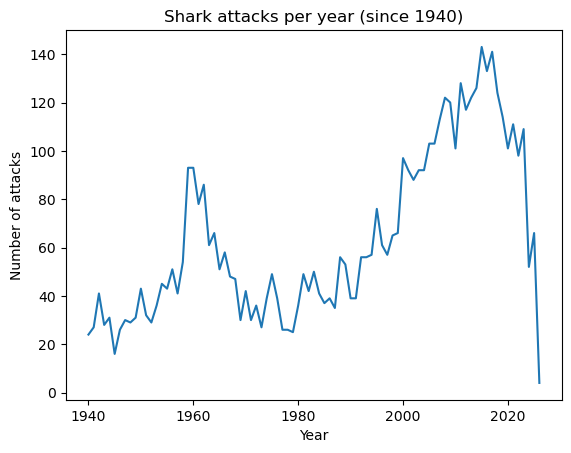

In [252]:
# Part 3 --------------------------------------------------------------------------------------------------

df['year'] = df['Year']

print(df.dtypes,'\n') 
print(df['year'].unique(), '\n')

df['year'] = pd.to_numeric(df['year'], errors='coerce') #Convert to numeric from string

# set implausible years to missing
df.loc[(df["year"] < 1500) | (df["year"] > 2026), "year"] = np.nan

# convert to integer-friendly dtype (keeps NaN)
df["year"] = df["year"].astype("Int64")

print(df['year'].unique(), '\n')

print(df['year'].head())
print(df['year'].tail())

df_1940 = df[df["year"] >= 1940].copy() #Only looking at attacks since 1940s
attacks_per_year = df_1940["year"].value_counts().sort_index() #Create a count of attacks per year, ordered from earliest year to latest

attacks_per_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.title("Shark attacks per year (since 1940)")
plt.show()


Question 3 Response:

Over time the number of attacks is increasing. Not till recent, there seems to be a decline of the number of attacks.

['?' '56' '55' '24' '26' '25' '61' '40' '13' '14' '50+' '54' '48' '57' '8'
 '63' '9' '39' '19' '7' '85' '69' '18' '66' '21' '37' '16' '20' '12' '42'
 '45' '30' '30+' '40+' '29' '35' '58' '17' '36' '23' '28' '60+' '27' '38'
 '68' '33' '15' '41' '43' 'Middle age' '49' '46' '65' '64' 'nan' '11' '32'
 '10' '62' '22' '52' '44' '47' '59' '50' '34' '30s' '20/30' '20s' '77'
 '60' '!2' '73' '50s' '67' '6' '53' '51' '31' '40s' 'teen' 'Teen' 'M' '!6'
 '!!' '71' '75' '45 and 15' '70' '4' '28 & 22' '22, 57, 31' '60s' "20's"
 '74' '9 & 60' 'a minor' '3' '82' '40?' '72' '18 months' '28 & 26' '5'
 '86' '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' '36 & 26'
 '8 or 10' '84' '' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s' '23 & 20'
 '7      &    31' '20?' "60's" '32 & 30' '16 to 18' '87' 'Elderly'
 'mid-20s' 'Ca. 33' '21 or 26' '>50' '18 to 22' 'adult' '9 & 12' '? & 19'
 '9 months' '25 to 35' '23 & 26' '1' '(adult)' '33 & 37' '25 or 28'
 '37, 67, 35, 27,  ? & 27' '21, 34,24 & 35' '30 & 32' '50 

<Axes: >

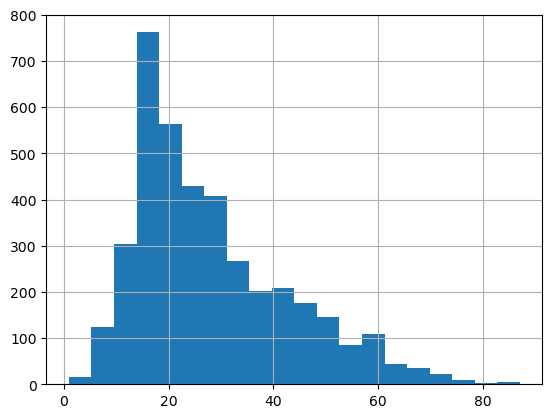

In [254]:
# Part 4 --------------------------------------------------------------------------------------------------

df['age'] = df['Age'].astype(str).str.strip()

print(df['age'].unique(), '\n')

df["age"] = pd.to_numeric(df["age"], errors="coerce") #This will help me get rid of everything that is not a numeric integer and has a string (strings will be converted to np.nan). Talked with TA

#Ensure that our data is within a resonable range
df.loc[(df["age"] < 0) | (df["age"] > 100), "age"] = np.nan

print(df['age'].unique())

df["age_missing"] = df["age"].isnull()
print(df['age_missing'].sum())

df['age'].hist(bins=20)


In [255]:
# Part 5 --------------------------------

# -----> What is M x 2 and also m, do I have to account for this? Is this the same as a single male???

df['sex'] = df['Sex'].astype(str).str.strip().replace(["nan", "m", "lli", "N", "."], np.nan)
df['sex'] = df['sex'].replace('M x 2', 'M') #Here I am replacing all instance of M x 2 as a "M", this was talked about with the TA

print(df['sex'].unique())

male_count = (df["sex"] == "M").sum()
print(male_count, '\n')

total_count = df['sex'].count()

total_missing = df['sex'].value_counts()

print(df['sex'].value_counts(), '\n')
print("Proportion Male: " + str(round(male_count/total_count , 2)))

['M' 'F' nan]
5671 

sex
M    5671
F     810
Name: count, dtype: int64 

Proportion Male: 0.88


Question 5 Response:

The proportion of victims that are male is roughly 0.88. 

In [256]:
#Part 6 ----------------------------------------------------------------------------

df['type'] = df['Type'].astype(str).str.strip().str.capitalize()
print(df['type'].unique(), '\n')

df.loc[~df["type"].isin(["Provoked", "Unprovoked"]), "type"] = "Unknown" #Turn everything that is outside of Unprovoked and Provoked and lump it as Unkown

print(df['type'].unique(), '\n')

total_unprovoked = (df['type'] == "Unprovoked").sum()
total_count = df['type'].count()

print("Proportion Unprovoked: " + str(round(total_unprovoked/total_count,2)))

df['type'].value_counts(normalize=True)

['Unprovoked' 'Provoked' 'Questionable' 'Watercraft' 'Sea disaster' 'Nan'
 '?' 'Unconfirmed' 'Unverified' 'Invalid' 'Under investigation' 'Boat'] 

['Unprovoked' 'Provoked' 'Unknown'] 

Proportion Unprovoked: 0.74


type
Unprovoked    0.738570
Unknown       0.170418
Provoked      0.091012
Name: proportion, dtype: float64

Question 6 Response:

The proportion of attacks that are unprovoked is around 0.74. 

In [257]:
#Part 7 ------------------------------------------------------------------------------------

df['fatal'] = df['Fatal Y/N'].astype(str).str.strip().str.capitalize()

df['fatal'] = df['fatal'].replace('Y x 2', 'Y') #Here the 'Y x 2' is the same as Y
df['fatal'] = df['fatal'].replace(['F', 'M', 'Nan', 'Nq', '2017'], 'Unknown')

print(df['fatal'].unique(), '\n')



['N' 'Y' 'Unknown'] 



In [258]:
#Part 8 -----------------

df['sex_new'] = df['Sex']
print(df['Sex'].unique())

df['sex_new'] = df['sex_new'].astype(str).str.strip().str.upper()

print(df['sex_new'].unique())

df.loc[~df["sex_new"].isin(["M", "F"]), "sex_new"] = "Unknown"

print(df['sex_new'].unique())

print(pd.crosstab(df['type'], df['sex_new'], normalize=True), '\n')
print(pd.crosstab(df['type'], df['fatal'], normalize=True), '\n')
print(pd.crosstab(df['sex'], df['fatal'], normalize=True), '\n')





['M' 'F' 'F ' 'M ' nan ' M' 'm' 'lli' 'M x 2' 'N' '.']
['M' 'F' 'NAN' 'LLI' 'M X 2' 'N' '.']
['M' 'F' 'Unknown']
sex_new            F         M   Unknown
type                                    
Provoked    0.004388  0.078132  0.008493
Unknown     0.013022  0.107148  0.050248
Unprovoked  0.097240  0.617410  0.023921 

fatal              N   Unknown         Y
type                                    
Provoked    0.086766  0.001274  0.002972
Unknown     0.063553  0.078415  0.028450
Unprovoked  0.548195  0.011182  0.179193 

fatal         N   Unknown         Y
sex                                
F      0.094893  0.010801  0.019287
M      0.610554  0.070977  0.193489 



Question 8 Response: 

From the type x sex table, unprovoked attacks are much more associated with men than women. The biggest cell is unprovoked-M = 0.617, compared with Unrpovoked-F = 0.097, so unprovoked incidents in this dataset are far more often recorded for male victims. 

From your type × fatal table, unprovoked attacks appear more likely to be fatal than provoked attacks: Unprovoked–Y = 0.179 versus Provoked–Y = 0.003 (with most provoked cases being non-fatal).

From your sex × fatal table, attacks on men are more likely to be fatal than attacks on women: M–Y = 0.177 compared with F–Y = 0.018 (though note there’s also an “Unknown” sex category).

Personally, I’m pro-shark. They’re important for ocean ecosystems, and this dataset highlights rare but memorable events—so the takeaway for me is to respect them and manage human risk (where/when people swim and how incidents get reported), not to treat sharks as “evil.”

In [259]:
#9. What proportion of attacks appear to be by white sharks? 
#(Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

shark_type = df['Species '].astype(str).str.strip()

#shark_type = shark_type.replace(["", "Unknown", "unkown", "nan"], np.nan)

print(shark_type.unique(), '\n')

species_words = shark_type.astype(str).str.lower().str.split()

def has_white(word_list):
    return "white" in word_list

is_white = species_words.apply(has_white)

print(is_white.value_counts(), '\n')

white_proportion = is_white.mean()

print("Proportion of attack by white sharks: " + str(round(white_proportion,2))) #The proportion reported here accounts for the na in the denominator as discussed with the TA



['Unknown' 'Great White Shark' 'Suspected Great White Shark' ...
 "12' tiger shark" 'Blue pointers'
 'Said to involve a grey nurse shark that leapt out of the water and  seized the boy but species identification is questionable'] 

Species 
False    6350
True      715
Name: count, dtype: int64 

Proportion of attack by white sharks: 0.1


Question 9 Response: 

Proportion of attack that appear to be by white sharks is 0.1

[***DECIDED TO GO WITH QUESTION 4***]

**Q3.** Open the "tidy_data.pdf" document in the repo, which is a paper called Tidy Data by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?
  8. Read Section 6. What is the "chicken-and-egg" problem with focusing on tidy data? What does Wickham hope happens in the future with further work on the subject of data wrangling?

**Q4.** Many important datasets contain a race variable, typically limited to a handful of values often including Black, White, Asian, Latino, and Indigenous. This question looks at data gathering efforts on this variable by the U.S. Federal government.

1. How did the most recent US Census gather data on race?

For the 2020 Census, the collected race/ethnicity used two separate questions: 1) asking whether a person is of Hispanic/Lation/Spanish origin, and 2) a separate race question. The race question let respondents mark one or more races and also write in origins, which helps capture more detailed identities than just the broad checkbox labels.

2. Why do we gather these data? What role do these kinds of data play in politics and society? Why does data quality matter?

Race and thenicity data are used to produce official statistics and to support federal reporting and civil rights compliance, and Census race/ethnicity counts are central to high-stakes decisions like political representation and how communities are understood and served. Data quality matter because errors and missingness can shift measured disparities and can distort decisions that depend on reliable denominators, especially for smaller groups whose counts are eaiser to mis-measure.

3. Please provide a constructive criticism of how the Census was conducted: What was done well? What do you think was missing? How should future large scale surveys be adjusted to best reflect the diversity of the population? Could some of the Census' good practices be adopted more widely to gather richer and more useful data?

What was done well: The 2020 cenuses improved question design and coding so people could provide more detailed reace/ethenicity responsees, and the "mark one or more + write-in orgins" design better reflect real identities than a single forced choice.

What could be better: The Census stuck with the two-question format (Hispanic origin seprate from race), which has long been debated and can be confusing for some respondents. Also, 2020 census did not add a separate Middle Eastern/North African (MENA) checkbox, even though many people write in MENA identities and the topic has been an ongoing policy dicussion. 

Future improvmenets: One promising direction is adopting updated federal standards and testing that supports richer categories (including MENA) and potentially a combined race/ethnicity approach where appropriate, while keeping self-identification and write-ins.

4. How did the Census gather data on sex and gender? Please provide a similar constructive criticism of their practices.

This appraoch can misclassify or even erase nonbinary and some trnsgender/intersec experiences by forcing everyone into a binary that may not match identity or lived reality. The Census Bureau has been researching sexual orientation and gender identity measurment in other contexts, which suggests awareness that current practice may be insufficient for representing population diversity.

5. When it comes to cleaning data, what concerns do you have about protected characteristics like sex, gender, sexual identity, or race? What challenges can you imagine arising when there are missing values? What good or bad practices might people adopt, and why?

Key concenrs are harm and misuse. Cleaning choices can accidentially erase smaller groups, force categories that don't fit, or create misleading comparisons. Missing values are often not random, people skip sensitive questions for patterned reasons, so treating missing as "doesn't exist" can bias results. Good practice is to preserve unkown/not reported data and document every recode, and be cautious about collapsing categories when it changes meaning, especially for groups with historical undercount or discrimination. 

6. Suppose someone invented an algorithm to impute values for protected characteristics like race, gender, sex, or sexuality. What kinds of concerns would you have?

I would worry about: 1) consent (people did not agree to have identity inferred), 2) bias amplification (models) learn from historically biased data and reproduce it), 3) feedback loops (imputed labels can influence decisions, then become "truth" in later datasets), 4) privacy risks (linkage/inference can deanonymize), and 5) legitimacy (race/gender are partly social and self0defined, predicition can be conceptually wrong even if "accurate"). At minimum, any such imputation would ned clear safegaurds like clear transparceny, auditability, and strong limits on downstream use. 